In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/20-digitalskysurvey.csv")

In [3]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [7]:
df = df.drop(["objid", "specobjid", "rerun", "camcol", "field", "run"], axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


In [9]:
df["class"].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

<Axes: xlabel='redshift', ylabel='ra'>

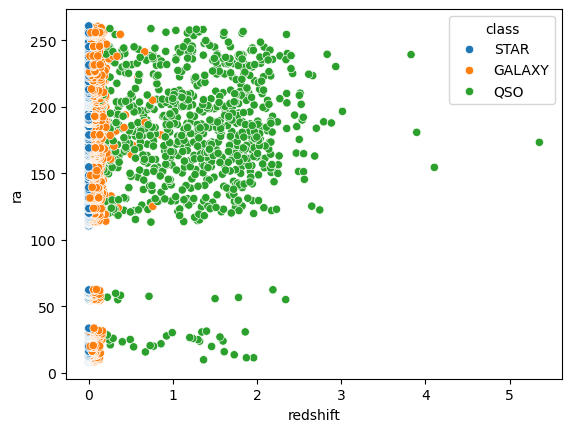

In [10]:
sns.scatterplot(data = df, x= "redshift", y= "ra", hue = "class")

<Axes: xlabel='redshift', ylabel='dec'>

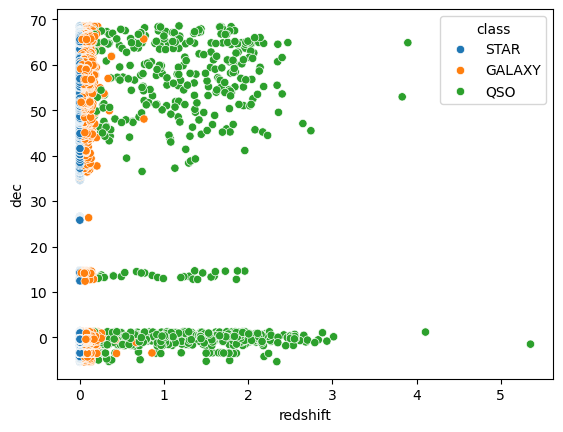

In [11]:
sns.scatterplot(data = df, x= "redshift", y= "dec", hue = "class")

<Axes: xlabel='redshift', ylabel='plate'>

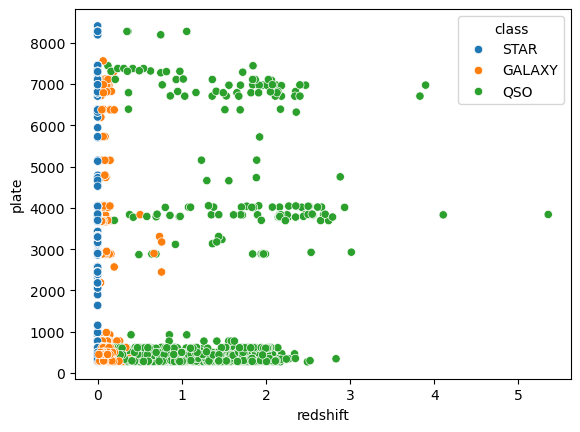

In [13]:
sns.scatterplot(data = df, x= "redshift", y= "plate", hue = "class")

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["class"] = le.fit_transform(df["class"])

In [15]:
df["class"].unique()

array([2, 0, 1])

In [16]:
df.corr()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
ra,1.000000,0.003596,0.031238,0.043909,0.047103,0.045731,0.042950,-0.043219,0.030307,-0.095329,-0.086887,0.057485
dec,0.003596,1.000000,0.035279,0.061875,0.063404,0.058292,0.056870,-0.058918,0.067021,0.088342,0.066147,0.155012
u,0.031238,0.035279,1.000000,0.849232,0.692379,0.602630,0.551483,-0.269044,0.163741,-0.129430,-0.168793,0.011301
g,0.043909,0.061875,0.849232,1.000000,0.958106,0.907419,0.879622,-0.099212,0.407576,-0.054981,-0.092772,0.047187
r,0.047103,0.063404,0.692379,0.958106,1.000000,0.977672,0.969197,0.049628,0.441080,0.019787,-0.009345,0.061081
i,0.045731,0.058292,0.602630,0.907419,0.977672,1.000000,0.981507,0.146791,0.431450,0.072958,0.050896,0.069977
z,0.042950,0.056870,0.551483,0.879622,0.969197,0.981507,1.000000,0.215758,0.424034,0.112397,0.095658,0.067980
class,-0.043219,-0.058918,-0.269044,-0.099212,0.049628,0.146791,0.215758,1.000000,-0.075510,0.585495,0.648768,0.053593
redshift,0.030307,0.067021,0.163741,0.407576,0.441080,0.431450,0.424034,-0.075510,1.000000,-0.038091,-0.057957,0.046532
plate,-0.095329,0.088342,-0.129430,-0.054981,0.019787,0.072958,0.112397,0.585495,-0.038091,1.000000,0.966881,0.229811


<Axes: >

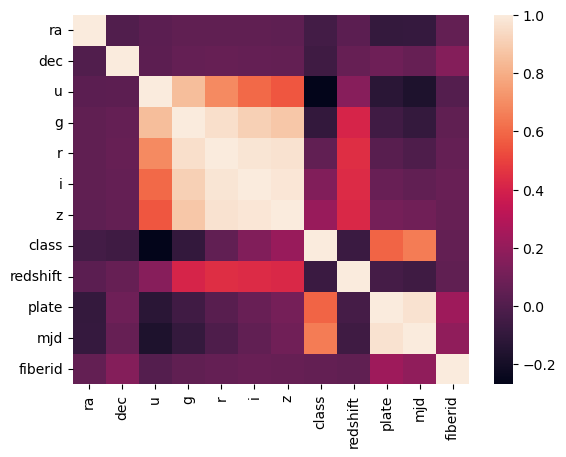

In [17]:
sns.heatmap(df.corr())

In [18]:
X = df.drop("class", axis = 1)
y = df["class"]

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size = 0.2
)

In [23]:
scaler = StandardScaler()

In [24]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
!pip install xgboost

In [29]:
from xgboost import XGBClassifier

In [31]:
xgb = XGBClassifier(n_estimators = 100)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [33]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("train_overfit: ", xgb.score(X_train, y_train))

Model accuracy score with default decision-trees : 0.991
[[990   3   3]
 [ 11 179   0]
 [  1   0 813]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       996
           1       0.98      0.94      0.96       190
           2       1.00      1.00      1.00       814

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000

train_overfit:  1.0


In [34]:
params = {
    "n_estimators" : [100, 200, 300, 500],
    "learning_rate" : [0.01, 0.1, 0.3, 0.5],
    "max_depth" : [5,8,12,20,30],
    "colsample_bytree" : [0.3,0.4,0.5,0.8,1]
}

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
grid = GridSearchCV(estimator= XGBClassifier(), param_grid = params, cv = 5, n_jobs= -1)

In [37]:
grid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.3, 0.4, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [38]:
y_pred = grid.predict(X_test)

In [39]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("train_overfit: ", grid.score(X_train, y_train))

Model accuracy score with default decision-trees : 0.9895
[[987   3   6]
 [ 11 179   0]
 [  1   0 813]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       996
           1       0.98      0.94      0.96       190
           2       0.99      1.00      1.00       814

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000

train_overfit:  1.0
